<a href="https://colab.research.google.com/github/claudiaglezbau-code/TFG_Dataset_Redes/blob/main/Datasets_TFG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Se importan las librerías necesarias y se definen constantes globales usadas por las funciones posteriores:
- `EPS`: tolerancia numérica para evitar divisiones por cero.
- `S0`: precio inicial del activo.
- `r`: tasa libre de riesgo.

In [ ]:
#Importar ,ibrerías necesarias
import numpy as np
from scipy import fftpack, stats, optimize
from math import pi
import csv, os, time
import pandas as pd

# Constantes globales
EPS = 1e-12
S0 = 100.0  # Precio inicial del activo
r = 0.0     # Tasa libre de riesgo


**Funciones de valoración**
En esta celda se definen las funciones para valorar opciones y la función característica del modelo de Heston, además de la rutina Carr–Madan para obtener precios por FFT.
Se incluyen:
- `precio_bs_call`: fórmula Black–Scholes para una call europea.
- `volatilidad_implícita_call`: inversión numérica de BSM para obtener volatilidad implícita.
- `caracteristica_heston`: función característica del modelo de Heston.
- `carr_madan_fft_precios`: método de Carr–Madan para calcular precios mediante FFT.

In [ ]:
# Celda de código: funciones de valoración

def precio_bs_call(S, K, r_local, sigma, T):
    # Fórmula Black–Scholes–Merton para una opción Call europea.
    if sigma <= 0 or T <= 0:
        return max(S - K * np.exp(-r_local * T), 0.0)
    d1 = (np.log(S / K) + (r_local + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * stats.norm.cdf(d1) - K * np.exp(-r_local * T) * stats.norm.cdf(d2)

def volatilidad_implícita_call(precio, S, K, r_local, T):
    # Inversión de la fórmula BSM para obtener la volatilidad implícita mediante búsqueda de raíz.
    intrinsic = max(S - K * np.exp(-r_local * T), 0.0)
    if precio <= intrinsic + 1e-14:
        return 0.0
    f = lambda vol: precio_bs_call(S, K, r_local, vol, T) - precio
    try:
        return optimize.brentq(f, 1e-8, 5.0, maxiter=200, xtol=1e-8)
    except Exception:
        return np.nan

def caracteristica_heston(phi, params, S0_local, r_local, T, Pnum=2):
    # Función característica del modelo de Heston para P1 o P2.
    kappa, theta, sigma, rho, v0 = params
    phi = np.array(phi, dtype=complex)
    i = 1j
    u = 0.5 if Pnum == 1 else -0.5
    b = kappa - rho * sigma if Pnum == 1 else kappa
    a = kappa * theta
    sigma2 = max(sigma**2, EPS)

    alpha = -0.5 * (phi**2) + i * u * phi
    beta = b - rho * sigma * i * phi
    d = np.sqrt(beta**2 - 2.0 * sigma2 * alpha)
    g = (beta - d) / (beta + d)

    exp_dt = np.exp(-d * T)
    one_minus_gexp = 1.0 - g * exp_dt
    one_minus_g = 1.0 - g

    # Ajustes para estabilidad numérica
    one_minus_gexp = np.where(np.abs(one_minus_gexp) < EPS, EPS, one_minus_gexp)
    one_minus_g = np.where(np.abs(one_minus_g) < EPS, EPS, one_minus_g)

    log_term = np.log(one_minus_gexp / one_minus_g)
    C = (1j * phi * r_local * T) + (a / sigma2) * ((beta - d) * T - 2.0 * log_term)
    D = ((beta - d) / sigma2) * (1.0 - exp_dt) / one_minus_gexp

    return np.exp(C + D * v0 + 1j * phi * np.log(S0_local))

def carr_madan_fft_precios(params, S0_local, r_local, T, alpha=1.5, N=2048, eta=0.25):
    # Implementación de Carr–Madan para obtener precios de opciones mediante FFT.
    i = 1j
    lambd = 2 * pi / (N * eta)
    b = N * lambd / 2
    v = np.arange(N) * eta
    phi = v - (alpha + 1) * i

    char_vals = caracteristica_heston(phi, params, S0_local, r_local, T, Pnum=2)
    numerator = np.exp(-r_local * T) * char_vals * np.exp(-i * b * v)
    denom = (alpha + i * v) * (alpha + i * v + 1)

    integrand = (numerator / denom) * eta
    fft_vals = fftpack.fft(integrand).real

    k = -b + np.arange(N) * lambd
    K = np.exp(k)
    precios = np.exp(-alpha * k) / pi * fft_vals
    return K, precios


**Generación de parámetros válidos (condición de Feller)**
Genera conjuntos de parámetros que cumplen la condición de Feller
2κθ>σ^2.

La función `generar_paramsets_validos` muestrea parámetros dentro de rangos razonables y filtra aquellos que cumplen la condición de Feller para garantizar estabilidad del proceso de varianza.

In [ ]:
# Celda de código: generación de parámetros válidos

def generar_paramsets_validos(n_needed, rng):
    # Genera conjuntos de parámetros que satisfacen 2*kappa*theta > sigma^2.
    valid_sets = []
    while len(valid_sets) < n_needed:
        # Rangos de muestreo para cada parámetro
        k = rng.uniform(0.5, 6.0)      # kappa (velocidad de reversión)
        t = rng.uniform(0.0005, 0.12)  # theta (varianza a largo plazo)
        s = rng.uniform(0.01, 0.8)     # sigma (volatilidad del proceso de varianza)
        r_corr = rng.uniform(-0.95, 0.0) # rho (correlación)
        v = rng.uniform(0.0005, 0.25)  # v0 (varianza inicial)

        # Aplicar condición de Feller
        if 2 * k * t > s**2:
            valid_sets.append([k, t, s, r_corr, v])

    return np.array(valid_sets)


**Generador de datasets (Opciones A, B, C)**
Función que crea archivos CSV con precios teóricos y precios con ruido, usando Carr–Madan para cada superficie.

`generar_dataset` construye un conjunto de observaciones para varias superficies de volatilidad:
- `target_n`: número total de filas deseadas.
- `strikes_per_surface`, `maturities_per_surface`: resolución de la superficie.
- `random_strikes`: si True, los strikes se muestrean aleatoriamente; si False, se usa una malla.
La función escribe un CSV con columnas de parámetros y precios.

In [ ]:
# Celda de código: generador de datasets

def generar_dataset(target_n, strikes_per_surface, maturities_per_surface, random_strikes=False, outfile_prefix="heston"):
    rng = np.random.default_rng(12345)
    obs_per_surface = strikes_per_surface * maturities_per_surface
    paramsets_needed = int(np.ceil(target_n / obs_per_surface))

    paramsets = generar_paramsets_validos(paramsets_needed, rng)
    maturity_grid = np.linspace(0.05, 2.0, maturities_per_surface)  # rejilla de vencimientos

    outfile = f"{outfile_prefix}_{target_n}_{time.strftime('%Y%m%d_%H%M%S')}.csv"
    header = ["kappa","theta","sigma","rho","v0","T","K","price","price_noisy"]

    written = 0
    with open(outfile, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(header)
        for params in paramsets:
            # Strikes aleatorios o en malla según la opción
            if random_strikes:
                strike_grid = rng.uniform(0.5 * S0, 1.5 * S0, size=strikes_per_surface)
            else:
                strike_grid = np.linspace(0.5 * S0, 1.5 * S0, strikes_per_surface)

            for Tm in maturity_grid:
                try:
                    K_grid, call_grid = carr_madan_fft_precios(params, S0, r, Tm)
                    precios_interp = np.interp(strike_grid, K_grid, call_grid)
                except:
                    continue

                for j, Kval in enumerate(strike_grid):
                    base_price = float(precios_interp[j])
                    # Añadir ruido simulado para representar precios de mercado
                    noisy_price = max(0.0, base_price * (1.0 + rng.normal(0.0, 0.01)))
                    writer.writerow([*params, float(Tm), float(Kval), base_price, noisy_price])
                    written += 1
                    if written >= target_n:
                        break
                if written >= target_n:
                    break
            if written >= target_n:
                break

    print(f"Finalizado: {outfile} ({written} filas)")
    return outfile


**Bloque principal de ejecución**

Ejecuta la generación de los tres datasets (A, B, C) y realiza comprobaciones finales sobre la condición de Feller.

In [ ]:
# Celda de código: ejecución principal

if __name__ == "__main__":
    start_all = time.time()

    # Opción A: grid fijo
    print("\nGenerando Opción A (Grid fijo)...")
    file_a = generar_dataset(50000, 25, 6, random_strikes=False, outfile_prefix="heston_A_feller")

    # Opción B: strikes aleatorios
    print("\nGenerando Opción B (Strikes aleatorios)...")
    file_b = generar_dataset(50000, 60, 6, random_strikes=True, outfile_prefix="heston_B_feller")

    # Opción C: generar set grande y muestrear
    print("\nGenerando Opción C (Muestreo de 200k a 50k)...")
    file_full = generar_dataset(200000, 60, 6, random_strikes=False, outfile_prefix="heston_full_feller")
    df_full = pd.read_csv(file_full)
    df_sampled = df_full.sample(n=50000, random_state=1).to_csv("heston_C_sampled_feller.csv", index=False)
    print("Muestreo de Opción C completado.")

    # Verificación técnica para A
    df_test = pd.read_csv(file_a)
    feller_ok = (2 * df_test['kappa'] * df_test['theta'] > df_test['sigma']**2).all()
    print(f"\n--- INFORME FINAL ---")
    print(f"Tiempo total: {time.time() - start_all:.1f} segundos")
    print(f"¿Cumplen todos los parámetros la condición de Feller?: {feller_ok}")
    print(f"Archivos listos para calibración.")

    # Verificación técnica para B
    df_test = pd.read_csv(file_b)
    feller_ok = (2 * df_test['kappa'] * df_test['theta'] > df_test['sigma']**2).all()
    print(f"\n--- INFORME FINAL ---")
    print(f"Tiempo total: {time.time() - start_all:.1f} segundos")
    print(f"¿Cumplen todos los parámetros la condición de Feller?: {feller_ok}")
    print(f"Archivos listos para calibración.")

    # Verificación técnica para full
    df_test = pd.read_csv(file_full)
    feller_ok = (2 * df_test['kappa'] * df_test['theta'] > df_test['sigma']**2).all()
    print(f"\n--- INFORME FINAL ---")
    print(f"Tiempo total: {time.time() - start_all:.1f} segundos")
    print(f"¿Cumplen todos los parámetros la condición de Feller?: {feller_ok}")
    print(f"Archivos listos para calibración.")



Generando Opción A (Grid fijo)...
Finalizado: heston_A_feller_50000_20260405_165054.csv (50000 filas)

Generando Opción B (Strikes aleatorios)...
Finalizado: heston_B_feller_50000_20260405_165101.csv (50000 filas)

Generando Opción C (Muestreo de 200k a 50k)...
Finalizado: heston_full_feller_200000_20260405_165103.csv (200000 filas)
Muestreo de Opción C completado.

--- INFORME FINAL ---
Tiempo total: 18.2 segundos
¿Cumplen todos los parámetros la condición de Feller?: True
Archivos listos para calibración.

--- INFORME FINAL ---
Tiempo total: 18.3 segundos
¿Cumplen todos los parámetros la condición de Feller?: True
Archivos listos para calibración.

--- INFORME FINAL ---
Tiempo total: 18.7 segundos
¿Cumplen todos los parámetros la condición de Feller?: True
Archivos listos para calibración.


**Análisis y comparación con Random Forest**

Las siguientes celdas contienen el código para cargar los CSV generados, crear características, entrenar un RandomForest y mostrar métricas y gráficos. Las funciones y prints se mantienen.

Se importan librerías adicionales para análisis y visualización. Se definen utilidades para:
- Resumir cobertura del dataset.
- Crear características para el modelo.
- Dividir por paramset y entrenar/evaluar un RandomForest.
Finalmente se ejecuta la comparación entre los archivos A/B/C y se muestran métricas y boxplots.

scikit-learn version: 1.6.1
mean_squared_error signature: (y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')

Procesando A heston_A_feller_50000_20260405_165054.csv


/tmp/ipykernel_1795/2024334511.py:93: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_ps = test.groupby(['kappa','theta','sigma','rho','v0']).apply(


A coverage: {'rows': 50000, 'paramsets_unique': 334, 'rows_per_paramset_min': 50, 'rows_per_paramset_median': 150, 'rows_per_paramset_max': 150, 'K_unique': 25, 'T_unique': 6}
A metrics: {'train_time_s': 13.97402024269104, 'val_mae': 0.3719631531277134, 'val_rmse': np.float64(0.514331513510246), 'val_r2': 0.999023255317017, 'test_mae': 0.3914415899024954, 'test_rmse': np.float64(0.5604915943187317), 'test_r2': 0.9988475255311339, 'test_per_paramset_mae_median': 0.3687046865794103, 'test_per_paramset_mae_95perc': np.float64(0.6645928897328828)}

Procesando B heston_B_feller_50000_20260405_165101.csv


/tmp/ipykernel_1795/2024334511.py:93: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_ps = test.groupby(['kappa','theta','sigma','rho','v0']).apply(


B coverage: {'rows': 50000, 'paramsets_unique': 139, 'rows_per_paramset_min': 320, 'rows_per_paramset_median': 360, 'rows_per_paramset_max': 360, 'K_unique': 8340, 'T_unique': 6}
B metrics: {'train_time_s': 11.932928562164307, 'val_mae': 0.5159213545163606, 'val_rmse': np.float64(0.7327447938944986), 'val_r2': 0.9978554745633855, 'test_mae': 0.5020240607443981, 'test_rmse': np.float64(0.6697847420547083), 'test_r2': 0.9980740737727075, 'test_per_paramset_mae_median': 0.4918370578231865, 'test_per_paramset_mae_95perc': np.float64(0.7346376785121672)}

Procesando C heston_full_feller_200000_20260405_165103.csv
C coverage: {'rows': 200000, 'paramsets_unique': 556, 'rows_per_paramset_min': 200, 'rows_per_paramset_median': 360, 'rows_per_paramset_max': 360, 'K_unique': 60, 'T_unique': 6}
C metrics: {'train_time_s': 44.26281118392944, 'val_mae': 0.42312318981843733, 'val_rmse': np.float64(0.6024837393690701), 'val_r2': 0.9985858086874843, 'test_mae': 0.438712322220296, 'test_rmse': np.float6

/tmp/ipykernel_1795/2024334511.py:93: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_ps = test.groupby(['kappa','theta','sigma','rho','v0']).apply(


,opt,rows,paramsets_unique,K_unique,T_unique,test_MAE,test_RMSE,median_paramset_MAE
0,A,50000,334,25,6,0.391442,0.560492,0.368705
2,C,200000,556,60,6,0.438712,0.621773,0.390843
1,B,50000,139,8340,6,0.502024,0.669785,0.491837


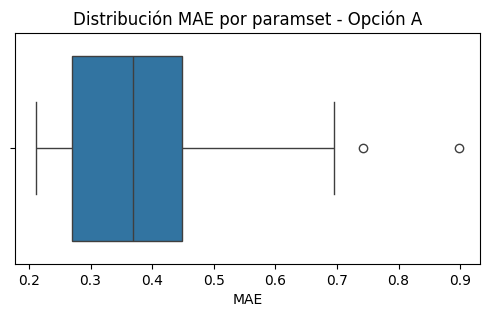

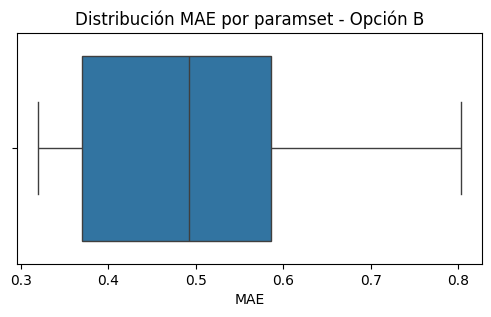

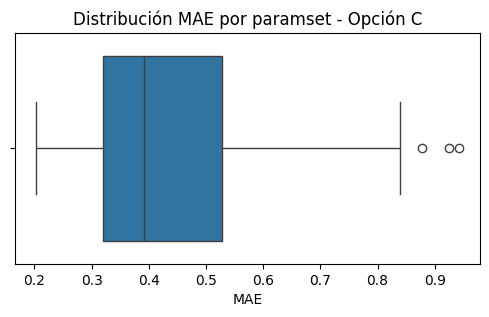

In [ ]:
# Celda de código: análisis y comparación

import os, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import inspect
import sklearn

# Comprobación rápida de versiones y firmas
print("scikit-learn version:", sklearn.__version__)
print("mean_squared_error signature:", inspect.signature(mean_squared_error))

S0 = 100.0
FILES = {
    "A": "heston_A_feller_50000_20260405_165054.csv",
    "B": "heston_B_feller_50000_20260405_165101.csv",
    "C": "heston_full_feller_200000_20260405_165103.csv"
}

def resumen_coverage(df):
    params = ['kappa','theta','sigma','rho','v0']
    n_paramsets = df[params].drop_duplicates().shape[0]
    counts_per_paramset = df.groupby(params).size()
    return {
        "rows": len(df),
        "paramsets_unique": n_paramsets,
        "rows_per_paramset_min": int(counts_per_paramset.min()),
        "rows_per_paramset_median": int(counts_per_paramset.median()),
        "rows_per_paramset_max": int(counts_per_paramset.max()),
        "K_unique": int(df['K'].nunique()),
        "T_unique": int(df['T'].nunique())
    }

def make_features(df):
    df = df.copy()
    df['log_moneyness'] = np.log(df['K'] / S0)
    df['sqrt_T'] = np.sqrt(df['T'].clip(lower=1e-12))
    df['log_theta'] = np.log(df['theta'].clip(lower=1e-8))
    df['log_v0'] = np.log(df['v0'].clip(lower=1e-8))
    return df

def split_by_paramset(df, seed=1):
    params = ['kappa','theta','sigma','rho','v0']
    paramsets = df[params].drop_duplicates().sample(frac=1, random_state=seed).reset_index(drop=True)
    n = len(paramsets)
    train_ps = paramsets.iloc[:int(0.7*n)]
    val_ps   = paramsets.iloc[int(0.7*n):int(0.85*n)]
    test_ps  = paramsets.iloc[int(0.85*n):]
    train = df.merge(train_ps, on=params, how='inner')
    val   = df.merge(val_ps, on=params, how='inner')
    test  = df.merge(test_ps, on=params, how='inner')
    return train, val, test

def train_and_eval(df):
    df = make_features(df)
    train, val, test = split_by_paramset(df)
    features = ['log_moneyness','sqrt_T','kappa','log_theta','sigma','rho','log_v0']
    X_train, y_train = train[features], train['price_noisy']
    X_val, y_val = val[features], val['price_noisy']
    X_test, y_test = test[features], test['price_noisy']

    model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=1, n_jobs=-1)
    t0 = time.time()
    model.fit(X_train, y_train)
    t_train = time.time() - t0

    preds_val = model.predict(X_val)
    preds_test = model.predict(X_test)

    # Calcular RMSE a partir de MSE
    mse_val = mean_squared_error(y_val, preds_val)
    val_rmse = np.sqrt(mse_val)
    mse_test = mean_squared_error(y_test, preds_test)
    test_rmse = np.sqrt(mse_test)

    metrics = {
        "train_time_s": t_train,
        "val_mae": mean_absolute_error(y_val, preds_val),
        "val_rmse": val_rmse,
        "val_r2": r2_score(y_val, preds_val),
        "test_mae": mean_absolute_error(y_test, preds_test),
        "test_rmse": test_rmse,
        "test_r2": r2_score(y_test, preds_test)
    }

    # Error por paramset en test
    test = test.copy()
    test['pred'] = preds_test
    per_ps = test.groupby(['kappa','theta','sigma','rho','v0']).apply(
        lambda g: mean_absolute_error(g['price_noisy'], g['pred'])
    ).rename('mae_per_paramset')

    metrics['test_per_paramset_mae_median'] = per_ps.median()
    metrics['test_per_paramset_mae_95perc'] = per_ps.quantile(0.95)
    return metrics, model, per_ps, (train, val, test)

# Ejecutar comparación
results = {}
for key, fname in FILES.items():
    if not os.path.exists(fname):
        print("No encontrado:", fname)
        continue
    print("\nProcesando", key, fname)
    df = pd.read_csv(fname)
    cov = resumen_coverage(df)
    metrics, model, per_ps, splits = train_and_eval(df)
    results[key] = {"coverage": cov, "metrics": metrics, "per_paramset_mae": per_ps}
    print(key, "coverage:", cov)
    print(key, "metrics:", metrics)

# Resumen comparativo
rows = []
for k,v in results.items():
    cov = v['coverage']; m = v['metrics']
    rows.append([k, cov['rows'], cov['paramsets_unique'], cov['K_unique'], cov['T_unique'],
                 round(m['test_mae'],6), round(m['test_rmse'],6), round(m['test_per_paramset_mae_median'],6)])
comp = pd.DataFrame(rows, columns=['opt','rows','paramsets_unique','K_unique','T_unique','test_MAE','test_RMSE','median_paramset_MAE'])
display(comp.sort_values('test_MAE'))

# Boxplots de MAE por paramset
for k,v in results.items():
    if 'per_paramset_mae' in v:
        plt.figure(figsize=(6,3))
        sns.boxplot(x=v['per_paramset_mae'].values)
        plt.title(f"Distribución MAE por paramset - Opción {k}")
        plt.xlabel("MAE")
        plt.show()


Configuración actual: 52 puntos por superficie.
Generando 1924 superficies para alcanzar el objetivo de 100k...
Generando 1924 superficies de volatilidad...
Archivo guardado: dataset_heston_100k.csv
Dataset guardado con éxito. Filas finales: 100000

--- INFORME DE SOLIDEZ ---
Total de filas: 100000
¿Condición de Feller cumplida en todo el set?: True
Violaciones de valor intrínseco: 0


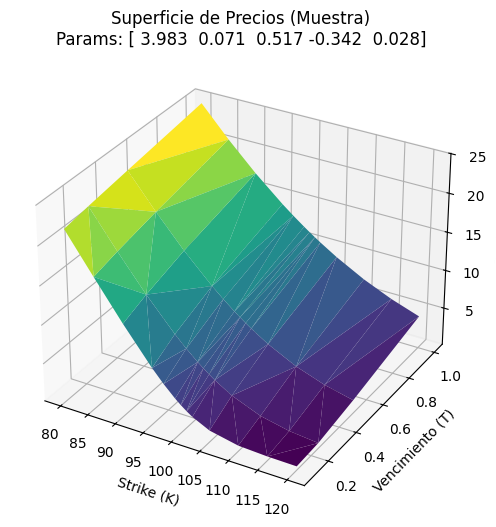

In [2]:

"""
Generador de Dataset Heston para Redes Neuronales
Configuración: Opción A (Grid Fijo)
"""

import numpy as np
from scipy import fftpack, stats
from math import pi
import csv, time
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN ESTRUCTURAL ---
S0 = 100.0
r = 0.0
EPS = 1e-12

# Rejilla solicitada
STRIKES_PCT = np.array([0.80, 0.85, 0.90, 0.95, 0.97, 0.99, 1.00, 1.01, 1.02, 1.05, 1.10, 1.15, 1.20])
MATURITIES = np.array([0.1, 0.25, 0.5, 1.0])

# --- NÚCLEO MATEMÁTICO (Heston + Carr-Madan) ---

def caracteristica_heston(phi, params, S0_local, r_local, T):
    """Función característica del modelo de Heston."""
    kappa, theta, sigma, rho, v0 = params
    phi = np.array(phi, dtype=complex)
    i = 1j
    u = -0.5
    b = kappa
    a = kappa * theta
    sigma2 = max(sigma**2, EPS)

    alpha = -0.5 * (phi**2) + i * u * phi
    beta = b - rho * sigma * i * phi
    d = np.sqrt(beta**2 - 2.0 * sigma2 * alpha)
    g = (beta - d) / (beta + d)

    exp_dt = np.exp(-d * T)
    one_minus_gexp = np.maximum(np.abs(1.0 - g * exp_dt), EPS)
    one_minus_g = np.maximum(np.abs(1.0 - g), EPS)

    log_term = np.log(one_minus_gexp / one_minus_g)
    C = (1j * phi * r_local * T) + (a / sigma2) * ((beta - d) * T - 2.0 * log_term)
    D = ((beta - d) / sigma2) * (1.0 - exp_dt) / (1.0 - g * exp_dt)

    return np.exp(C + D * v0 + 1j * phi * np.log(S0_local))

def carr_madan_fft(params, S0_local, r_local, T, alpha=1.5, N=4096, eta=0.2):
    """Transformada Rápida de Fourier para obtención de precios."""
    i = 1j
    lambd = 2 * pi / (N * eta)
    b = N * lambd / 2
    v = np.arange(N) * eta
    phi = v - (alpha + 1) * i

    char_vals = caracteristica_heston(phi, params, S0_local, r_local, T)
    numerator = np.exp(-r_local * T) * char_vals * np.exp(-i * b * v)
    denom = (alpha + i * v) * (alpha + i * v + 1)

    integrand = (numerator / denom) * eta
    fft_vals = fftpack.fft(integrand).real

    k = -b + np.arange(N) * lambd
    K = np.exp(k)
    precios = np.exp(-alpha * k) / pi * fft_vals
    return K, precios

# --- GENERACIÓN Y VALIDACIÓN ---

def generar_paramsets(n_needed, seed=42):
    """Genera parámetros que cumplen estrictamente la condición de Feller."""
    rng = np.random.default_rng(seed)
    valid_sets = []
    while len(valid_sets) < n_needed:
        k = rng.uniform(0.5, 5.0)      # kappa
        t = rng.uniform(0.01, 0.15)    # theta
        s = rng.uniform(0.01, 0.6)     # sigma
        rho = rng.uniform(-0.9, -0.1)  # rho
        v0 = rng.uniform(0.01, 0.2)    # v0

        if 2 * k * t > s**2:  # Condición de Feller
            valid_sets.append([k, t, s, rho, v0])
    return np.array(valid_sets)

def crear_dataset_nn(n_surfaces, filename="dataset_heston_nn.csv"):
    paramsets = generar_paramsets(n_surfaces)
    strike_grid = S0 * STRIKES_PCT

    header = ["kappa", "theta", "sigma", "rho", "v0", "T", "K", "price"]
    data_rows = []

    print(f"Generando {n_surfaces} superficies de volatilidad...")

    for params in paramsets:
        for T in MATURITIES:
            try:
                K_fft, P_fft = carr_madan_fft(params, S0, r, T)
                # Interpolamos para obtener los precios en los strikes exactos de la rejilla
                precios_interp = np.interp(strike_grid, K_fft, P_fft)

                for i, K_val in enumerate(strike_grid):
                    data_rows.append([*params, T, K_val, max(0.0, precios_interp[i])])
            except:
                continue

    df = pd.DataFrame(data_rows, columns=header)
    df.to_csv(filename, index=False)
    print(f"Archivo guardado: {filename}")
    return df

def validar_datos(df):
    """Comprobaciones de solidez de los datos."""
    print("\n--- INFORME DE SOLIDEZ ---")
    print(f"Total de filas: {len(df)}")

    # 1. Verificar Feller
    feller = (2 * df['kappa'] * df['theta'] > df['sigma']**2).all()
    print(f"¿Condición de Feller cumplida en todo el set?: {feller}")

    # 2. Verificar Arbitraje elemental (Precio > Intrinseco)
    intrinseco = (S0 - df['K']).clip(lower=0)
    violaciones = (df['price'] < intrinseco - 1e-5).sum()
    print(f"Violaciones de valor intrínseco: {violaciones}")

    # 3. Visualización de una superficie aleatoria
    sample_params = df.iloc[0][["kappa", "theta", "sigma", "rho", "v0"]].values
    subset = df[(df['kappa'] == sample_params[0]) & (df['theta'] == sample_params[1])]

    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_trisurf(subset['K'], subset['T'], subset['price'], cmap='viridis')
    ax.set_title(f"Superficie de Precios (Muestra)\nParams: {sample_params.round(3)}")
    ax.set_xlabel('Strike (K)')
    ax.set_ylabel('Vencimiento (T)')
    ax.set_zlabel('Precio')
    plt.show()

# --- EJECUCIÓN ---
if __name__ == "__main__":
# 1. Definimos el objetivo
    total_objetivo = 100000

    # Calculamos cuántos puntos genera cada combinación de parámetros (superficie)
    puntos_por_superficie = len(STRIKES_PCT) * len(MATURITIES)

    # 2. Calculamos cuántas superficies (paramsets) necesitamos
    # 100.000 / 52 = 1923.07 -> Necesitamos 1924 para no quedarnos cortos
    n_superficies = int(np.ceil(total_objetivo / puntos_por_superficie))

    print(f"Configuración actual: {puntos_por_superficie} puntos por superficie.")
    print(f"Generando {n_superficies} superficies para alcanzar el objetivo de 100k...")

    # 3. Llamamos a la función de creación
    df_final = crear_dataset_nn(n_superficies, filename="dataset_heston_100k.csv")

    # 4. Ajuste exacto
    if len(df_final) > total_objetivo:
        df_final = df_final.head(total_objetivo)
        df_final.to_csv("dataset_heston_100k.csv", index=False)
        print(f"Dataset guardado con éxito. Filas finales: {len(df_final)}")

    # 5. Validación de los datos generados
    validar_datos(df_final)

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import joblib

def normalizar_dataset(input_file="dataset_heston_nn.csv"):
    df = pd.read_csv(input_file)

    # 1. Ingeniería de Características (Feature Engineering)
    S0 = 100.0
    df['moneyness'] = df['K'] / S0

    # 2. Selección de columnas para la Red Neuronal
    # Entradas (X): [kappa, theta, sigma, rho, v0, T, moneyness]
    # Salida (y): [price / S0] (Normalizar el precio por el spot)
    X_cols = ['kappa', 'theta', 'sigma', 'rho', 'v0', 'T', 'moneyness']
    y_col = ['price']

    X = df[X_cols].values
    y = df[y_col].values / S0  # Escalamos el precio relativo al activo

    # 3. División en conjuntos de Entrenamiento y Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 4. Ajuste del Escalador (Min-Max Scaling)
    # Llevamos todo al rango [0, 1] o [-1, 1] para estabilidad numérica
    scaler_x = MinMaxScaler(feature_range=(0, 1))
    X_train_scaled = scaler_x.fit_transform(X_train)
    X_test_scaled = scaler_x.transform(X_test)

    # 5. Guardar escaladores y datos

    joblib.dump(scaler_x, 'scaler_x_heston.pkl')

    print("--- RESUMEN DE NORMALIZACIÓN ---")
    print(f"Forma de X_train: {X_train_scaled.shape}")
    print(f"Rango de las entradas: [{X_train_scaled.min()}, {X_train_scaled.max()}]")
    print(f"Precio normalizado (media): {y_train.mean():.4f}")

    return X_train_scaled, X_test_scaled, y_train, y_test

# Ejecutar
if __name__ == "__main__":
    X_train, X_test, y_train, y_test = normalizar_dataset()

--- RESUMEN DE NORMALIZACIÓN ---
Forma de X_train: (20800, 7)
Rango de las entradas: [0.0, 1.0]
Precio normalizado (media): 0.1080


In [3]:
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras import layers, models

# --- 1. GENERACIÓN DEL DATASET AMPLIADO (52.000 filas) ---

def preparar_datos_completos(df, S0=100.0):
    # Ingeniería de variables: Moneyness y Precio Relativo
    df['moneyness'] = df['K'] / S0
    df['target'] = df['price'] / S0

    # Definimos Entradas (X) y Salida (y)
    X_cols = ['kappa', 'theta', 'sigma', 'rho', 'v0', 'T', 'moneyness']
    X = df[X_cols].values
    y = df['target'].values.reshape(-1, 1)

    # División 80/20
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Normalización Min-Max [0, 1]
    scaler_x = MinMaxScaler()
    X_train = scaler_x.fit_transform(X_train_raw)
    X_test = scaler_x.transform(X_test_raw)


    joblib.dump(scaler_x, 'scaler_heston_50k.pkl')

    return X_train, X_test, y_train, y_test

# --- 2. DEFINICIÓN DE LA RED NEURONAL  ---

def construir_red_neuronal(input_dim):
    model = models.Sequential([
        # Capa de entrada + Primera capa oculta
        layers.Dense(128, activation='relu', input_shape=(input_dim,)),

        # Capas ocultas intermedias
        layers.Dense(128, activation='relu'),
        layers.Dense(128, activation='relu'),

        # Capa de salida
        layers.Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

# --- 3. FLUJO DE EJECUCIÓN ---

# Supongamos que df_final es el DataFrame generado anteriormente con 1000 superficies
# X_train, X_test, y_train, y_test = preparar_datos_completos(df_final)

# modelo_heston = construir_red_neuronal(X_train.shape[1])

# history = modelo_heston.fit(
#     X_train, y_train,
#     validation_data=(X_test, y_test),
#     epochs=100,
#     batch_size=64,
#     verbose=1
# )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iniciando entrenamiento con arquitectura de 4 capas...
Epoch 1/200
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0523 - mae: 0.1312 - val_loss: 0.0074 - val_mae: 0.0678
Epoch 2/200
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0051 - mae: 0.0558 - val_loss: 0.0038 - val_mae: 0.0482
Epoch 3/200
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0028 - mae: 0.0416 - val_loss: 0.0035 - val_mae: 0.0473
Epoch 4/200
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0020 - mae: 0.0349 - val_loss: 0.0017 - val_mae: 0.0321
Epoch 5/200
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0014 - mae: 0.0289 - val_loss: 0.0016 - val_mae: 0.0319
Epoch 6/200
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0011 - mae: 0.0263 - val_loss: 0.0026 - val_mae: 0.0410
Epoch 7/200
333/333 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 9.3642e-04 - mae: 0.0239 - val_loss: 9.4047e-04 - val_mae: 0.0242
Epoch 8/200
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.2829e-04 - mae: 0.0211 - val_loss: 0.0019

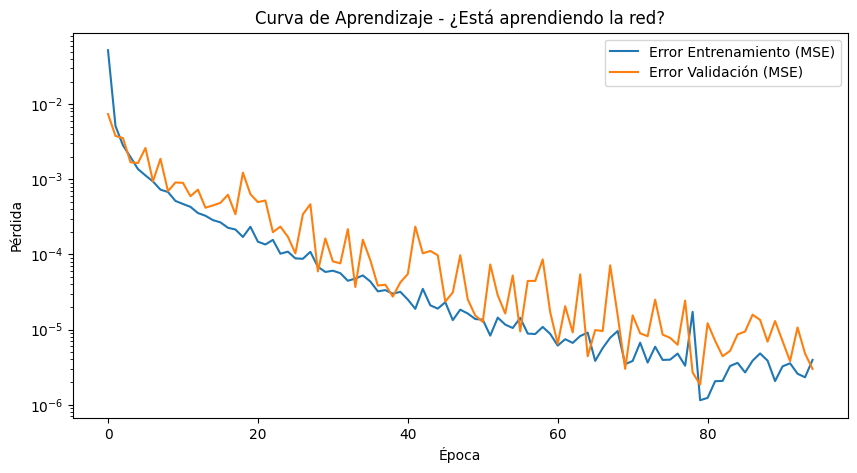

['escalador_heston.pkl']

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# --- CONFIGURACIÓN ---
S0 = 100.0
ARCHIVO_DATASET = "dataset_heston_100k.csv"

# 1. CARGA Y TRANSFORMACIÓN
def preparar_datos_para_nn(path):
    df = pd.read_csv(path)

    # Creamos las mismas features sólidas de tu análisis RF
    X = pd.DataFrame()
    X['log_moneyness'] = np.log(df['K'] / S0)
    X['sqrt_T'] = np.sqrt(df['T'].clip(lower=1e-12))
    X['kappa'] = df['kappa']
    X['log_theta'] = np.log(df['theta'].clip(lower=1e-8))
    X['sigma'] = df['sigma']
    X['rho'] = df['rho']
    X['log_v0'] = np.log(df['v0'].clip(lower=1e-8))

    # Objetivo: Precio normalizado
    y = df['price'] / S0
    return X, y

X_raw, y = preparar_datos_para_nn(ARCHIVO_DATASET)

# 2. NORMALIZACIÓN Z-SCORE (Media 0, Desviación 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.15, random_state=42)

# --- CONSTRUCCIÓN DE LA RED (4 capas ocultas, 128 neuronas cada una) ---

model = models.Sequential([
    # Capa 1
    layers.Dense(128, activation='elu', input_shape=(X_train.shape[1],), kernel_initializer='he_normal'),

    # Capas 2, 3 y 4 (Profundidad incrementada)
    layers.Dense(128, activation='elu', kernel_initializer='he_normal'),
    layers.Dense(128, activation='elu', kernel_initializer='he_normal'),
    layers.Dense(128, activation='elu', kernel_initializer='he_normal'),

    # Capa de salida
    layers.Dense(1, activation='linear')
])

# Usamos un learning rate ligeramente más bajo (0.0005) para que la red
# pueda "pulir" el error en las capas más profundas sin oscilar
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

# Ajustamos el EarlyStopping para que sea un poco más paciente con la red profunda
stop_callback = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

print("Iniciando entrenamiento con arquitectura de 4 capas...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=200, # Subimos épocas para aprovechar la profundidad
    batch_size=256,
    callbacks=[stop_callback],
    verbose=1
)

# 5. VERIFICACIÓN VISUAL
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Error Entrenamiento (MSE)')
plt.plot(history.history['val_loss'], label='Error Validación (MSE)')
plt.yscale('log')
plt.title('Curva de Aprendizaje - ¿Está aprendiendo la red?')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

# Guardar para usar en la calibración
model.save('modelo_heston_final.h5')
joblib.dump(scaler, 'escalador_heston.pkl')